# Figure S3

![Full Figure](../figures/suppS3_FULL.png)

## Code For Figure S3: Raw Fixation, Violation, and Rig Data

**Goal:** Display per-animal raw fixation duration and violation rate across all days in the Fixation Growth curriculum, with rig-switch events marked.

| Panel | Description | Data source |
|-------|-------------|-------------|
| (full figure) | All Legacy + FixGrower animals; max fixation (left y), violation rate (right y), rig switches (gray dashed vertical) | `trials_df`, `days_df` |

**Outputs:** `figures/suppS3_raw_fix_rig_viol_data.png`

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from fixation_grower import config
from fixation_grower.io import load_days_df, load_trials_df
from fixation_grower.plotting import plot_fixation_and_violations, save_figure
from fixation_grower.transforms import compute_days_relative_to_stage

sns.set_context(
    "notebook",
    rc={
        "font.size": 18,
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "axes.titleweight": "bold",
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "lines.linewidth": 2,
        "lines.markersize": 7,
    },
)

In [ ]:
tdf = load_trials_df(stages="all")
tdf["date"] = pd.to_datetime(tdf["date"])
ddf = load_days_df(stages="all")
trial_rig_df = tdf.merge(
    ddf[["animal_id", "stage", "date", "rigid"]],
    on=["animal_id", "stage", "date"],
)
trial_rig_df = compute_days_relative_to_stage(trial_rig_df, stage=5)

## Figure — Per-animal fixation, violation, and rig-switch data

Stages 5–7 only (`stage > 4 and stage < 8`). Left column: Legacy animals; right column: FixGrower. X-axis: days in Fixation Growth curriculum relative to Stage 5.

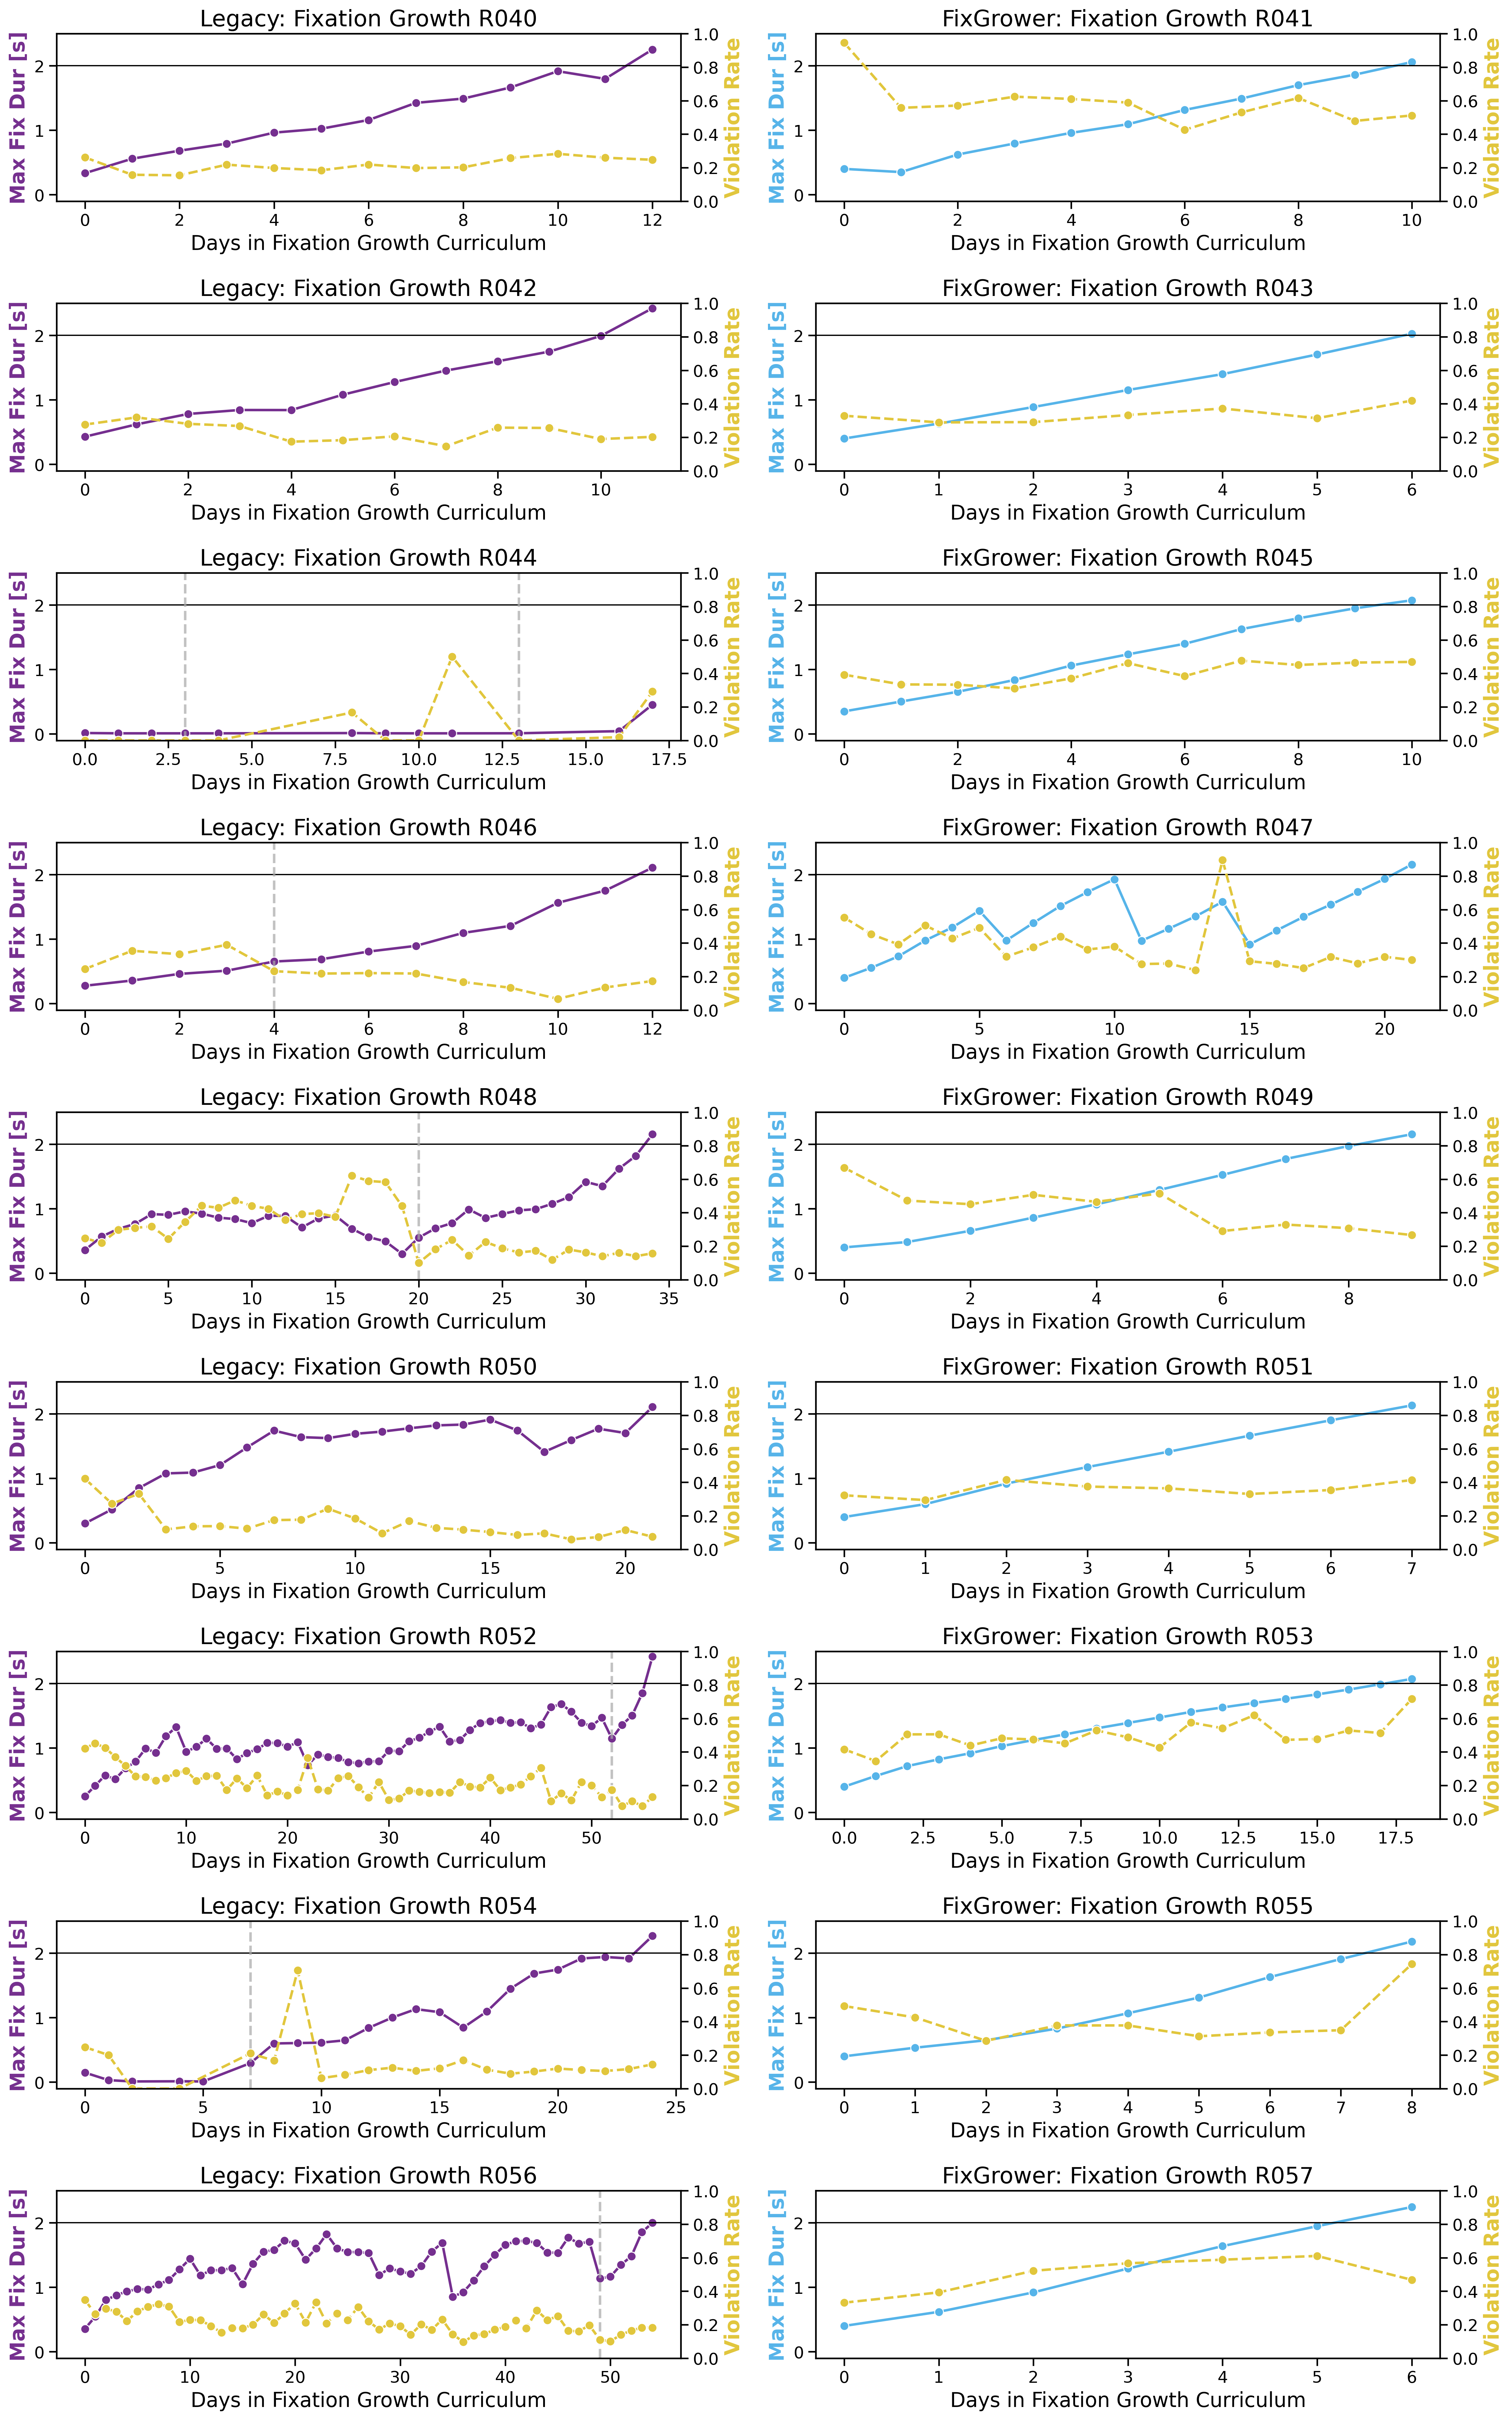

In [3]:
n_rows = len(config.LEGACY_ANIMALS)
fig, axs = plt.subplots(n_rows, 2, figsize=(17, 3 * n_rows), dpi=300)

for row, animal in enumerate(config.LEGACY_ANIMALS):
    df = trial_rig_df.query(
        "fix_experiment == 'Legacy' and stage > 4 and stage < 8 and animal_id == @animal"
    )
    plot_fixation_and_violations(axs[row, 0], df, "Legacy")
    axs[row, 0].set_title(f"Legacy: Fixation Growth {animal}")

for row, animal in enumerate(config.FIXGROWER_ANIMALS):
    df = trial_rig_df.query(
        "fix_experiment == 'FixGrower' and stage > 4 and stage < 8 and animal_id == @animal"
    )
    plot_fixation_and_violations(axs[row, 1], df, "FixGrower")
    axs[row, 1].set_title(f"FixGrower: Fixation Growth {animal}")

plt.tight_layout()
save_figure(fig, "suppS3_raw_fix_rig_viol_data")
plt.show()